In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

C:\Users\user\AppData\Roaming\Python\Python313\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [2]:
df = pd.read_csv("loan.csv")
df.head(2)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    str    
 1   Gender             601 non-null    str    
 2   Married            611 non-null    str    
 3   Dependents         599 non-null    str    
 4   Education          614 non-null    str    
 5   Self_Employed      582 non-null    str    
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    str    
 12  Loan_Status        614 non-null    str    
dtypes: float64(4), int64(1), str(8)
memory usage: 83.4 KB


In [4]:
df.describe()
# give info ONLY about Numerical columns

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [5]:
df.shape
# gives (no. of rows, no. of cols)

(614, 13)

In [6]:
df.size
# no. of rows * no. of cols = total no. of elements present

7982

In [7]:
print(df.duplicated().sum())

0


In [8]:
df.drop("Loan_ID", axis=1, inplace=True)
df.head(2)

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N


In [9]:
x = df.iloc[:, :-1] # I/P data
y = df["Loan_Status"] # O/P data

print("Shape of x:", x.shape)
print("Shape of y:", y.shape)

Shape of x: (614, 11)
Shape of y: (614,)


In [10]:
x.columns

Index(['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed',
       'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area'],
      dtype='str')

In [11]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.20, random_state=42)

In [12]:
x_train.head(2)

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
83,Male,Yes,0,Graduate,No,6000,2250.0,265.0,360.0,NaN,Semiurban
90,Male,Yes,0,Graduate,No,2958,2900.0,131.0,360.0,1.0,Semiurban


In [13]:
x_test.head(2)

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
350,Male,Yes,0,Graduate,No,9083,0.0,228.0,360.0,1.0,Semiurban
377,Male,Yes,0,Graduate,No,4310,0.0,130.0,360.0,NaN,Semiurban


In [14]:
y_train.head(2)

83    N
90    Y
Name: Loan_Status, dtype: str

In [15]:
y_test.head(2)

350    Y
377    Y
Name: Loan_Status, dtype: str

In [16]:
print("x_train shape:", x_train.shape)
print("x_test shape:", x_test.shape)
print("y_train shape:", y_train.shape) # O/P: (491,) --> no value after ','  , coz y_train and y_test are 'Series', not 'DataFrame'
print("y_test shape:", y_test.shape) # 0.2 * 614 --> 123, so 113 data rows gone for 'Testing'

x_train shape: (491, 11)
x_test shape: (123, 11)
y_train shape: (491,)
y_test shape: (123,)


# Handling Missing values

In [17]:
x_train.isnull().sum()

Gender               12
Married               1
Dependents           11
Education             0
Self_Employed        24
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           16
Loan_Amount_Term     12
Credit_History       40
Property_Area         0
dtype: int64

# * FILLING NULL VALUES IN COLUMNS USING MEAN OR MEDIAN OR MODE
Filling the missing values in numerical or categorical

⚫ For Numerical data --> mean , meadian
1) normally distributed value --> use mean
2) not normally(i.e. skewed) distributed value --> use median

⚫ For Categorical data --> mode, backward filling, forward filling
1) backward filling --> df = df.fillna(method="bfill") --> data of below row filled in above row
2) forward filling --> df = df.fillna(method="ffill") --> data of above row filled in below row
3) mode (best)

Use:

Mean → clean, balanced data

Median → skewed data or outliers

### 1) Handling Null values in Categorical column

In [18]:
# Separating the categorical data (Object type)
cat_x_train = x_train.select_dtypes(include=['object'])
cat_x_train.tail(3)

C:\Users\user\AppData\Local\Temp\ipykernel_3936\1630577250.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_x_train = x_train.select_dtypes(include=['object'])


,Gender,Married,Dependents,Education,Self_Employed,Property_Area
270,Female,No,0,Graduate,No,Urban
435,Female,NaN,NaN,Graduate,No,Semiurban
102,Male,Yes,NaN,Graduate,No,Urban


In [19]:
cat_x_train.isnull().sum()

Gender           12
Married           1
Dependents       11
Education         0
Self_Employed    24
Property_Area     0
dtype: int64

In [20]:
x_train["Gender"].mode()

0    Male
Name: Gender, dtype: str

In [21]:
x_train["Gender"].fillna(x_train["Gender"].mode()[0], inplace=True) # mode()[0] is done, coz if the mode gives 2 O/Ps , [0] selects the first mode value

C:\Users\user\AppData\Local\Temp\ipykernel_3936\565493630.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  x_train["Gender"].fillna(x_train["Gender"].mode()[0], inplace=True) # mode()[0] is done, coz if the mode gives 2 O/Ps , [0] selects the first mode value


83       Male
90       Male
227      Male
482      Male
464      Male
        ...  
71       Male
106      Male
270    Female
435    Female
102      Male
Name: Gender, Length: 491, dtype: str

In [22]:
# We can also apply the loop to fill all the Categorical columns with their Mode
for col in cat_x_train.columns: # instead of using 'df_categorical.columns', I used 'df.select_dtypes(include=['object']).columns', so that it will be automatically updated in the working dataset
    most_freq = x_train[col].mode()[0]
    x_train[col] = x_train[col].fillna(most_freq)
    x_test[col] = x_test[col].fillna(most_freq)

## Train data fill

In [23]:
x_train.select_dtypes(include=['object']).tail(2)

C:\Users\user\AppData\Local\Temp\ipykernel_3936\1398604634.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  x_train.select_dtypes(include=['object']).tail(2)


,Gender,Married,Dependents,Education,Self_Employed,Property_Area
435,Female,Yes,0,Graduate,No,Semiurban
102,Male,Yes,0,Graduate,No,Urban


In [24]:
x_train.select_dtypes(include=['object']).isnull().sum()

C:\Users\user\AppData\Local\Temp\ipykernel_3936\1667386174.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  x_train.select_dtypes(include=['object']).isnull().sum()


Gender           0
Married          0
Dependents       0
Education        0
Self_Employed    0
Property_Area    0
dtype: int64

# Test data fill

In [25]:
x_test.select_dtypes(include=['object']).tail(2)

C:\Users\user\AppData\Local\Temp\ipykernel_3936\766826536.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  x_test.select_dtypes(include=['object']).tail(2)


,Gender,Married,Dependents,Education,Self_Employed,Property_Area
11,Male,Yes,2,Graduate,No,Urban
333,Male,Yes,0,Graduate,No,Urban


In [26]:
x_test.select_dtypes(include=['object']).isnull().sum()

C:\Users\user\AppData\Local\Temp\ipykernel_3936\157264906.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  x_test.select_dtypes(include=['object']).isnull().sum()


Gender           0
Married          0
Dependents       0
Education        0
Self_Employed    0
Property_Area    0
dtype: int64

### 2) Handling Null values in Numerical column

In [27]:
# Separating the numerical data (Numeric type)
num_x_train = x_train.select_dtypes(include=['int64', 'float64'])
num_x_train.head(2)

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
83,6000,2250.0,265.0,360.0,NaN
90,2958,2900.0,131.0,360.0,1.0


In [28]:
num_x_train.isnull().sum()

ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           16
Loan_Amount_Term     12
Credit_History       40
dtype: int64

In [29]:
# check skew value:
num_x_train['LoanAmount'].skew()

np.float64(2.6112842614330396)

### Interpretation:  
If SKEW VALUE is:

Around 0 → data is symmetric → use Mean

Greater than +1 or less than −1 → highly skewed → use Median

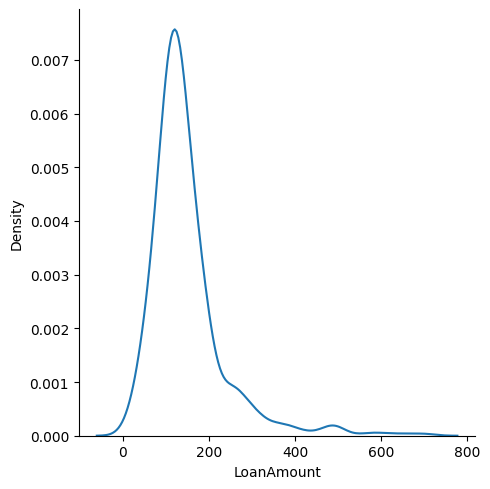

In [30]:
sns.displot(num_x_train['LoanAmount'], kind="kde")

Data for LoanAmount is +vely skewed (also we can see skew value --> (2.67) > (+1)) , so use Median

In [31]:
fill_null1 = x_train['LoanAmount'].median()
x_train['LoanAmount'] = x_train['LoanAmount'].fillna(fill_null1)
x_test['LoanAmount'] = x_test['LoanAmount'].fillna(fill_null1)

In [32]:
fill_null2 = x_train['Loan_Amount_Term'].mode()[0]
x_train['Loan_Amount_Term'] = x_train['Loan_Amount_Term'].fillna(fill_null2)
x_test['Loan_Amount_Term'] = x_test['Loan_Amount_Term'].fillna(fill_null2)

fill_null3 = x_train['Credit_History'].mode()[0]
x_train['Credit_History'] = x_train['Credit_History'].fillna(fill_null3)
x_test['Credit_History'] = x_test['Credit_History'].fillna(fill_null3)

For above task, we can also use SimpleImputer() from sklearn lib. It also help to directly fill values at the time of DEPLOYMENT, 
if not I/P by the user.